# Step 4 – Final evaluation and error analysis

**Goal:** measure both models **once** on the held-out test set (never used for training or model selection) and understand the remaining errors.

In [ ]:
# Setup: make the project package importable and fix random seeds
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from eurosat_cnn.config import CLASSES, DATA_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, SEED
keras.utils.set_random_seed(SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Keras", keras.__version__, "| data folder:", DATA_DIR)

## 4.1 Test-set evaluation
`evaluate()` computes accuracy, a per-class report and the confusion matrix, and saves figures and `reports/metrics_<model>.json`.

In [ ]:
from eurosat_cnn.evaluate import evaluate, plot_history, write_results_markdown

results = [evaluate(name, DATA_DIR) for name in ["baseline", "improved"] if (MODELS_DIR / f"{name}.keras").exists()]
plot_history(["baseline", "improved"])
write_results_markdown(results)
pd.DataFrame([{"model": r["model"], "test accuracy": r["test_accuracy"], "macro F1": r["macro_f1"]} for r in results])

model	test accuracy	macro F1
0	baseline	0.8822	0.8781
1	improved	0.9667	0.9664

## 4.2 Per-class F1 scores

In [3]:
f1 = pd.DataFrame({r["model"]: r["per_class_f1"] for r in results})
ax = f1.plot.barh(figsize=(8, 5), color=["#8a959b", "#2f7f6f"][:len(results)])
ax.set(xlabel="F1 score", xlim=(0.5, 1.0), title="F1 per class on the test set"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()
f1.round(3)

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_39268\3432095801.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


,baseline,improved
AnnualCrop,0.877,0.953
Forest,0.953,0.987
HerbaceousVegetation,0.852,0.951
Highway,0.778,0.966
Industrial,0.918,0.979
Pasture,0.868,0.974
PermanentCrop,0.788,0.928
Residential,0.960,0.983
River,0.821,0.960
SeaLake,0.966,0.983


## 4.3 Confusion matrix (improved model)

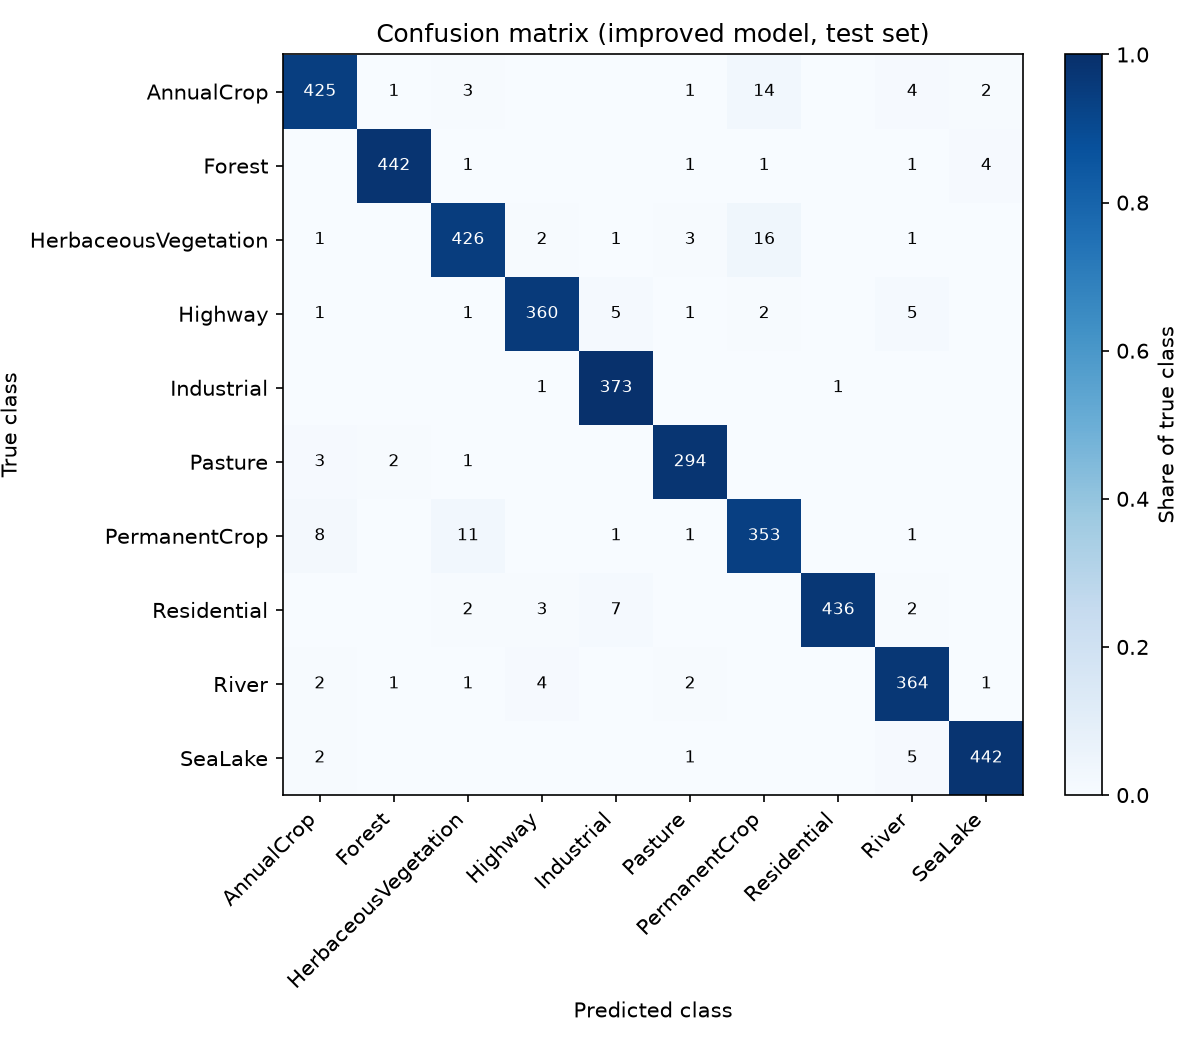

In [4]:
from IPython.display import Image as Show
Show(filename=str(FIGURES_DIR / "confusion_matrix_improved.png"), width=600)

## 4.4 Which errors does the model make?

In [5]:
best = max(results, key=lambda r: r["test_accuracy"])
pd.DataFrame(best["top_confusions"])

,true,predicted,count
0,HerbaceousVegetation,PermanentCrop,16
1,AnnualCrop,PermanentCrop,14
2,PermanentCrop,HerbaceousVegetation,11
3,PermanentCrop,AnnualCrop,8
4,Residential,Industrial,7


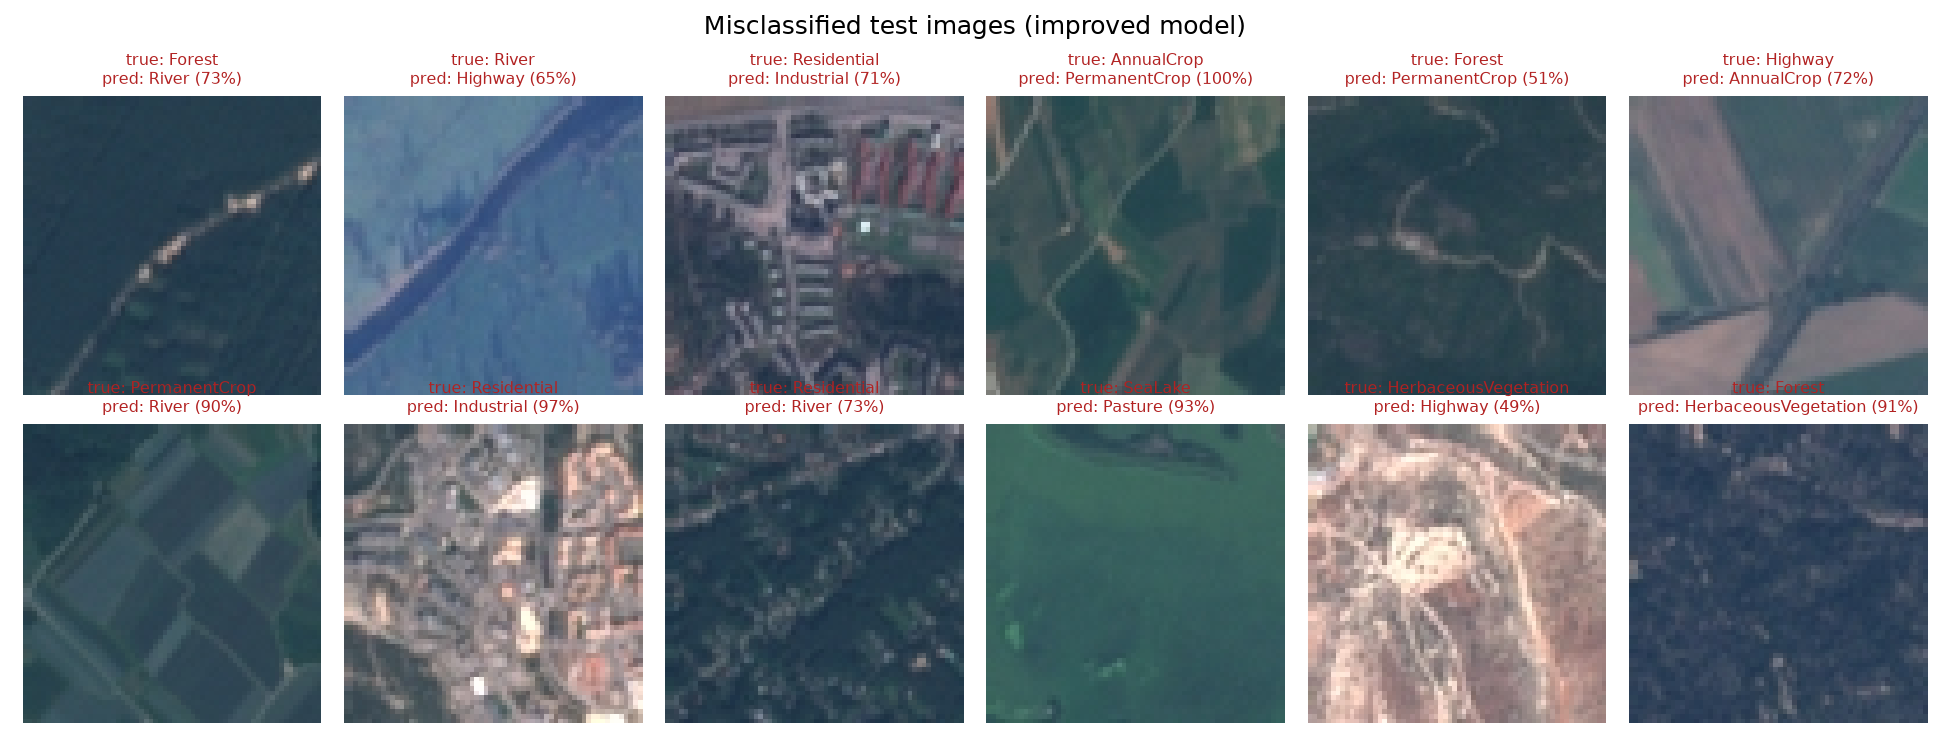

In [6]:
Show(filename=str(FIGURES_DIR / f"misclassified_examples_{best['model']}.png"), width=900)

## 4.5 Results table for the README
Copy the table below into the *Results* section of `README.md`.

In [7]:
print((REPORTS_DIR / "results.md").read_text())

| Model | Parameters | Epochs | Training time | Test accuracy | Macro F1 |
|---|---:|---:|---:|---:|---:|
| Baseline CNN | 1,143,242 | 15 | 16.3 min (CPU) | **88.22%** | 0.878 |
| Improved CNN | 577,514 | 30 | 162.1 min (CPU) | **96.67%** | 0.966 |

Most frequent confusions (improved model):

- HerbaceousVegetation predicted as PermanentCrop: 16 images
- AnnualCrop predicted as PermanentCrop: 14 images
- PermanentCrop predicted as HerbaceousVegetation: 11 images



## 📝 Conclusions
*Fill in after running:*
- Final test accuracy and macro F1 of both models: …
- Which classes are hardest, and why (look at the misclassified tiles)? …
- Are some "errors" actually ambiguous or mislabelled tiles? …
- What would you try next (transfer learning, all 13 spectral bands, larger input)? …